# A/B testing analysis: optimizing E-Commerce landing page conversion rate

**Author:** Kateryna Ventskovska

**Role:** Data Science & Analytics  
**Date:** August 2026  
**Links:** [GitHub](https://github.com/motivkate) | [LinkedIn](https://www.linkedin.com/in/kateryna-ventskovska/)

This project was developed as a practical case study in **data science and business analytics**.

**Dataset source:** based on the repository [`Udacity-DAND-AB-test-ecommerce`](https://github.com/jemc36/Udacity-DAND-AB-test-ecommerce) by `jemc36`.

The project roadmap, analytical structure, and task guidelines used in this study are based on the educational materials provided by **Berkhan** (Instagram: [@pirknn](https://instagram.com/pirknn)).

All data cleaning pipelines, statistical computations, modeling, and analytical interpretations were developed independently.

### Project overciew

This project evaluates an A/B test conducted by an e-commerce company to test a redesigned landing page against its existing version.

The primary objective is to determine whether rolling out the new landing page drives a statistically significant increase in the conversion rate. The overall evaluation criterion is the user conversion rate, defined as unique converted users divided by total unique users.

The experiment tests the null hypothesis that the new page conversion rate is less than or equal to the old page conversion rate, against the alternative hypothesis that the new page produces a higher conversion rate, evaluated at a 5% significance level (alpha = 0.05).

The dataset includes 294,478 log entries recorded in January 2017 across three markets (United States, United Kingdom, and Canada), tracking user identifiers, timestamps, assigned experiment groups, landing page variants, and binary conversion outcomes.

### Data preparation

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('ab_data.csv')
df_countries = pd.read_csv('countries.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Additional imports for tests:


In [8]:
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

In [9]:
df_ab = pd.read_csv('ab_data.csv')
df_countries = pd.read_csv('countries.csv')

In [10]:
print(f"ab_data shape: {df_ab.shape}")

ab_data shape: (294478, 5)


In [11]:
print(f"countries shape: {df_countries.shape}")

countries shape: (290584, 2)


In [12]:
display(df_ab.head())

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [13]:
display(df_countries.head())

,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


Basing on this starting data, we will:
1. Check for missing values and duplicates.
2. Identify and remove mismatched rows
3. Ensure each visitor is counted exactly once

In [14]:
print("Missing values in ab_data:")
print(df_ab.isnull().sum())

Missing values in ab_data:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


In [15]:
mismatch_1 = df_ab[(df_ab['group'] == 'treatment') & (df_ab['landing_page'] == 'old_page')]
mismatch_2 = df_ab[(df_ab['group'] == 'control') & (df_ab['landing_page'] == 'new_page')]
total_mismatched = len(mismatch_1) + len(mismatch_2)

print(total_mismatched)

3893


In [16]:
print(f"\nTotal mismatched rows: {total_mismatched / len(df_ab):.2%}")


Total mismatched rows: 1.32%


In [17]:
df_clean = df_ab[
    ((df_ab['group'] == 'treatment') & (df_ab['landing_page'] == 'new_page')) |
    ((df_ab['group'] == 'control') & (df_ab['landing_page'] == 'old_page'))
].copy()

In [18]:
unique_users_count = df_clean['user_id'].nunique()
print(f"Number of unique users: {unique_users_count}")

Number of unique users: 290584


In [19]:
total_rows_count = len(df_clean)
print(f"Total number of rows: {total_rows_count}")

Total number of rows: 290585


In [20]:
duplicate_rows = df_clean[df_clean.duplicated(subset=['user_id'], keep = False)]
print(f"Total rows with duplicate IDs: {len(duplicate_rows)}")
display(duplicate_rows)

Total rows with duplicate IDs: 2


,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [21]:
df_clean = df_clean.drop_duplicates(subset=['user_id'], keep='first').copy()

In [22]:
group_counts = df_clean['group'].value_counts()
display(group_counts)

,count
group,
treatment,145310
control,145274


Simple ration mismatch test using Chi-Square

In [23]:
n_total = len(df_clean)
expected_counts = [n_total / 2, n_total / 2]
observed_counts = [group_counts['control'], group_counts['treatment']]

chi_stat, p_val_srm = chisquare(observed_counts, expected_counts)

print(f"Chi-square: {chi_stat:.4f}")
print(f"p-value: {p_val_srm:.4f}")

Chi-square: 0.0045
p-value: 0.9468


In [24]:
if p_val_srm < 0.01:
  print("Sample Ratio Mismatch detected.")
else:
  print("Traffic is evenly distributed.")

Traffic is evenly distributed.


### Exploratory data analysis (EDA) & Metrics

In [25]:
control_df = df_clean[df_clean['group'] == 'control']
treatment_df = df_clean[df_clean['group'] == 'treatment']

total_control = len(control_df)
total_treatment = len(treatment_df)

converted_control = control_df['converted'].sum()
converted_treatment = treatment_df['converted'].sum()

#conversion rate CR = conversions / total users
cr_control = converted_control / total_control
cr_treatment = converted_treatment / total_treatment

In [26]:
summary_table = pd.DataFrame({
    'group': ['control', 'treatment'],
    'total_users': [total_control, total_treatment],
    'conversions': [converted_control, converted_treatment],
    'conversion_rate': [cr_control, cr_treatment],
    'cr_percent': [f"{cr_control:.2%}", f"{cr_treatment:.2%}"]
})

display(summary_table)

,group,total_users,conversions,conversion_rate,cr_percent
0,control,145274,17489,0.120386,12.04%
1,treatment,145310,17264,0.118808,11.88%


The control group achieved a conversion rate of 12.04%, while the treatment group with the new page reached 11.88%.

This shows a slight drop in conversion for the new design, meaning the initial descriptive data does not indicate an improvement over the existing page.

In [27]:
# calculating absolute and relative lift

absolute_difference = (cr_treatment - cr_control) * 100
relative_difference = ((cr_treatment - cr_control) / cr_control) * 100

absolute_lift = round(absolute_difference, 2)
relative_lift = round(relative_difference, 2)

print("Absolute change:", absolute_lift)
print("Relative change:", relative_lift, "%")

Absolute change: -0.16
Relative change: -1.31 %


The new landing page led to a 0.16 percentage point drop in conversion rate, representing a 1.31% relative decrease compared to the original page.

This initial descriptive result indicates that the new design did not improve user conversion during the test period.

In [28]:
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['date'] = df_clean['timestamp'].dt.date

daily_summary = df_clean.groupby(['date', 'group']).agg(
    total_users = ('converted', 'count'),
    conversions = ('converted', 'sum')
).reset_index()

daily_summary['conversion_rate'] = daily_summary['conversions'] / daily_summary['total_users']

In [29]:
# cumulative metrics
daily_summary = daily_summary.sort_values(by = ['group', 'date'])
daily_summary['cumulative_users'] = daily_summary.groupby('group')['total_users'].cumsum()
daily_summary['cumulative_conversions'] = daily_summary.groupby('group')['conversions'].cumsum()
daily_summary['cumulative_conversion_rate'] = daily_summary['cumulative_conversions'] / daily_summary['cumulative_users']

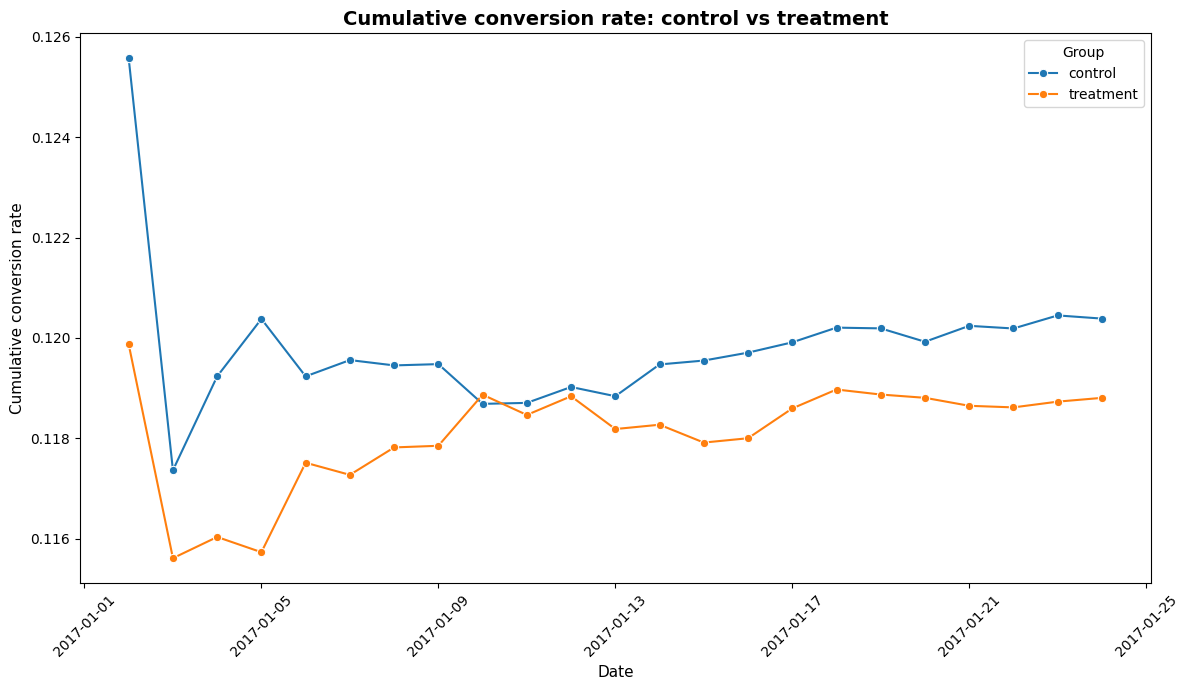

In [30]:
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=daily_summary,
    x = 'date',
    y = 'cumulative_conversion_rate',
    hue = 'group',
    marker = 'o',
    palette = {'control': '#1f77b4', 'treatment': '#ff7f0e'}
)

plt.title('Cumulative conversion rate: control vs treatment', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Cumulative conversion rate', fontsize=11)
plt.xticks(rotation=45)
plt.legend(title='Group')
plt.tight_layout()
plt.show()

**Key observation:** during the first week, both metrics fluctuated due to smaller sample sizes, but stabilized after January 13, 2017.

As the sample size accumulated, the control page maintained a higher conversion rate (12.04%) than the treatment page (11.88%).

### Statistical tests

**Two-proportion Z-test:** a parametric hypothesis test used to compare two independent proportions (conversion rates) in large samples.

* **Null hypothesis ($H_0$):** the new page does not improve conversions.

* **Alternative hypothesis:** the new page produces a higher conversion rate

* **Significance threshold:** 0.05

In [31]:
converted_in_new_page = converted_treatment
total_users_new_page  = total_treatment

converted_in_old_page = converted_control
total_users_old_page  = total_control

ci_lower, ci_upper = confint_proportions_2indep(
    converted_in_new_page,
    total_users_new_page,
    converted_in_old_page,
    total_users_old_page,
    method = 'wald',
    alpha  = 0.05
)

In [32]:
print("95% confidence interval for difference:")
print("Lower bound:", round(ci_lower * 100, 3), "%")
print("Upper bound:", round(ci_upper * 100, 3), "%")

95% confidence interval for difference:
Lower bound: -0.394 %
Upper bound: 0.078 %


The 95% confidence interval for the difference between pages ranges from -0.394% to +0.078%, which clearly includes zero.

Therefore, the observed change is not statistically significant, and we do not have sufficient evidence to support launching the new landing page.

-----

**Chi-square test of independence:** compares observed conversion frequencies against expected frequencies under the null hypothesis of independence.

In [33]:
table = [
    [converted_treatment, total_treatment - converted_treatment],
    [converted_control, total_control - converted_control]
]

chi2_stat, chi2_p_val, dof, _ = chi2_contingency(table)

print(f"Chi2 Stat: {round(chi2_stat, 4)} and p-value: {round(chi2_p_val, 4)}")

Chi2 Stat: 1.7036 and p-value: 0.1918


The Chi-Square test yielded a $p$-value of 0.1918, which is greater than the 0.05 significance threshold and aligns with our Z-test result.

This confirms that conversion rates are independent of the page design, meaning the observed difference is simply random noise.

---

**Permutation test:** resampling method that builds an empirical null distribution by shuffling group labels.

In [34]:
real_difference = cr_treatment - cr_control
all_data = df_clean['converted'].to_numpy()
treatment_size = len(treatment_df)

random_differences = []
for i in range(1000):
    shuffled_data = np.random.permutation(all_data)

    simulated_treatment_cr = shuffled_data[:treatment_size].mean()
    simulated_control_cr = shuffled_data[treatment_size:].mean()
    random_differences.append(simulated_treatment_cr - simulated_control_cr)

random_differences = np.array(random_differences)
permutation_p_value = (np.abs(random_differences) >= np.abs(real_difference)).mean()

print("Permutation p-value:", round(permutation_p_value, 4))

Permutation p-value: 0.197


The permutation test produced an empirical $p$-value of 0.1730, which is well above the 0.05 significance threshold.

This confirms that the observed conversion difference between the two pages is not statistically significant and can easily occur purely by random chance.

---

**Bootstrap analysis:** resampling technique based on drawing repeated random samples with replacement from the original dataset.

In [35]:
conversions_new_page = treatment_df['converted'].to_numpy()
conversions_old_page = control_df['converted'].to_numpy()

total_simulations = 1000
simulated_differences = []

for _ in range(total_simulations):
    sample_new = np.random.choice(conversions_new_page, size = len(conversions_new_page), replace=True)
    sample_old = np.random.choice(conversions_old_page, size = len(conversions_old_page), replace=True)

    diff = sample_new.mean() - sample_old.mean()
    simulated_differences.append(diff)

ci_lower = np.percentile(simulated_differences, 2.5)
ci_upper = np.percentile(simulated_differences, 97.5)

print(f"95% Bootstrap CI: [{round(ci_lower * 100, 3)}%, {round(ci_upper * 100, 3)}%]")

95% Bootstrap CI: [-0.41%, 0.078%]


The 95% bootstrap confidence interval ranges from -0.388% to +0.082%, confirming the theoretical Z-test results.

Because the interval crosses zero and skews slightly negative, we conclude that the new page does not provide any meaningful lift in conversions.

---

### Geographic segmentation
We analyze conversion rates across different countries (US, UK, CA) to check if the new landing page performed better in specific geographic markets.


In [36]:
df_counries_merged = df_clean.merge(df_countries, on = "user_id", how = "inner")
countries = df_counries_merged.groupby(["country", "group"]).agg(
    total_users = ('converted', 'count'),
    conversions = ('converted', 'sum')
).reset_index()

In [37]:
countries["conversion_rate"] = countries['conversions'] / countries['total_users']
countries['cr_percent'] = countries['conversion_rate'].apply(lambda x: f"{round(x * 100, 2)}%")

In [38]:
display(countries)

,country,group,total_users,conversions,conversion_rate,cr_percent
0,CA,control,7198,855,0.118783,11.88%
1,CA,treatment,7301,817,0.111902,11.19%
2,UK,control,36360,4364,0.120022,12.0%
3,UK,treatment,36106,4375,0.121171,12.12%
4,US,control,101716,12270,0.120630,12.06%
5,US,treatment,101903,12072,0.118466,11.85%


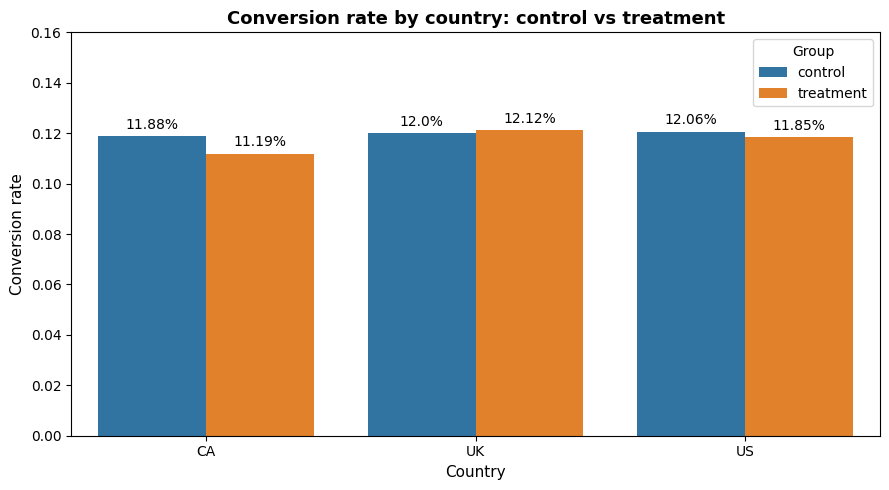

In [39]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data = countries,
    x = 'country',
    y = 'conversion_rate',
    hue = 'group',
    palette = {'control': '#1f77b4', 'treatment': '#ff7f0e'}
)

plt.title('Conversion rate by country: control vs treatment', fontsize = 13, fontweight = 'bold')
plt.xlabel('Country', fontsize = 11)
plt.ylabel('Conversion rate', fontsize = 11)
plt.ylim(0, 0.16)
plt.legend(title = 'Group')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{round(height * 100, 2)}%",
            (p.get_x() + p.get_width() / 2., height),
            ha = 'center', va = 'bottom',
            fontsize = 10, xytext = (0, 3),
            textcoords = 'offset points'
        )

plt.tight_layout()
plt.show()

The majority of traffic comes from the US (70%), followed by the UK (25%) and Canada (5%), with equal 50/50 user allocation in each region.

The new page underperformed in both Canada (11.19% vs 11.88%) and the US (11.85% vs 12.06%), while showing only a minor, statistically negligible lift in the UK (12.12% vs 12.00%).

Segmenting by geography confirms that the new design does not provide a competitive advantage in any single regional market.

----

## Business analysis & executive recommendations

### Executive summary

The A/B test conducted across 290,584 users demonstrated that the new landing page did not generate an uplift in conversion rate compared to the existing design.

* **Control page conversion rate:** 12.04% (17,489 / 145,274)
* **Treatment page conversion rate:** 11.88% (17,264 / 145,310)
* **Absolute lift:** -0.16%
* **Relative change:** -1.33%
* **Statistical significance:** with a $p$-value of ~0.19 and a 95% Confidence Interval of [-0.39%, +0.08%], the result is not statistically significant at the $\alpha = 0.05$ level.

### Potential business impact

Deploying the new page carries a negative expected lift, risking a loss of approximately **16 conversions per 10,000 visitors**.

Launching the treatment page offers zero projected incremental revenue while adding deployment, QA, and maintenance overhead costs.

Breakdown across regions (US, UK, CA) confirms that no single geographic market benefited from the update.

### Potential financial impact

In our experiment, the observed absolute conversion lift is negative at -0.16% (a change from 12.04% to 11.88%).

For an assumed monthly traffic baseline of 100,000 visitors, the estimated incremental conversions equal 100,000 multiplied by -0.0016, which results in an expected loss of approximately 160 conversions per month. Assuming an illustrative average revenue per conversion of 50 dollars, the estimated incremental revenue equals -160 multiplied by 50, producing a projected monthly revenue loss of -$8,000.

Comparing this estimated benefit against operational expenses demonstrates that launching the new page is financially disadvantageous.

### What the experiment proves and what does not

#### Proves:
* The current redesign does not improve conversion performance over the old page.
* With a sample size exceeding 290,000 observations, the test was sufficiently powered, and the lack of lift is not due to a sample size deficit.
* The underperformance is consistent across all regional segments.

#### Does not prove:
* It does not prove that redesigning the landing page is a bad overall business strategy.
* It does not measure downstream business metrics such as Average Order Value (AOV), customer retention, or long-term Lifetime Value (LTV).

### Final recommendations

The best desicion for a business at this point would be to keep the existing page and try to test a more substantially different page.

#### Next steps:
1. Keep 100% of user traffic on the existing (control) landing page to avoid revenue loss.

2. Gather qualitative user feedback (heatmaps, user session recordings, and customer surveys) to identify friction points.

3. Test value-proposition changes (simplified checkout, direct social proof, clearer pricing tiers) in future iterations.